In [162]:
import os
import sys
import scipy.io
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
from PIL import Image
import numpy as np
import tensorflow as tf
import pprint
from tensorflow.keras.applications.vgg19 import preprocess_input
%matplotlib inline

In [163]:
tf.random.set_seed(272)
pp = pprint.PrettyPrinter(indent=4)
img_size = 400
vgg = tf.keras.applications.VGG19(include_top=False, input_shape=(img_size, img_size, 3), weights='imagenet')
vgg.trainable = False

In [164]:
def compute_content_cost(content_output, generated_output):
    """
    Arguments:
    a_C -- tensor of dimension (1, n_H, n_W, n_C), hidden layer activations representing content of the image C
    a_G -- tensor of dimension (1, n_H, n_W, n_C), hidden layer activations representing content of the image G

    Returns:
    J_content -- scalar that you compute using equation 1 above.
    """
    a_C = content_output[-1]
    a_G = generated_output[-1]
    _, n_H, n_W, n_C = a_G.get_shape().as_list()
    a_C_unrolled = tf.reshape(a_C, shape=[-1, n_H * n_W, n_C])
    a_G_unrolled = tf.reshape(a_G, shape=[-1, n_H * n_W, n_C])
    J_content = (1 / (4 * n_H * n_W * n_C)) * tf.reduce_sum(tf.square(tf.subtract(a_C_unrolled, a_G_unrolled)))
    return J_content

In [165]:
def gram_matrix(A):
    """
    Argument:
    A -- matrix of shape (n_C, n_H*n_W)

    Returns:
    GA -- Gram matrix of A, of shape (n_C, n_C)
    """
    GA = tf.matmul(A, tf.transpose(A))
    return GA

In [166]:
def compute_layer_style_cost(a_S, a_G):
    """
    Arguments:
    a_S -- tensor of dimension (1, n_H, n_W, n_C), hidden layer activations representing style of the image S
    a_G -- tensor of dimension (1, n_H, n_W, n_C), hidden layer activations representing style of the image G

    Returns:
    J_style_layer -- tensor representing a scalar value, style cost defined above by equation (2)
    """
    _, n_H, n_W, n_C = a_G.get_shape().as_list()
    a_S = tf.transpose(tf.reshape(a_S, shape=[n_H * n_W, n_C]))
    a_G = tf.transpose(tf.reshape(a_G, shape=[n_H * n_W, n_C]))
    GS = gram_matrix(a_S)
    GG = gram_matrix(a_G)
    J_style_layer = (1 / (4 * (n_C ** 2) * (n_H * n_W) ** 2)) * tf.reduce_sum(tf.square(tf.subtract(GS, GG)))
    return J_style_layer

In [167]:
STYLE_LAYERS = [
    ('block1_conv1', 0.2),
    ('block2_conv1', 0.2),
    ('block3_conv1', 0.2),
    ('block4_conv1', 0.2),
    ('block5_conv1', 0.2)]

In [168]:
def compute_style_cost(style_image_output, generated_image_output, STYLE_LAYERS=STYLE_LAYERS):
    """
    Computes the overall style cost from several chosen layers

    Arguments:
    style_image_output -- List, a collection of 6 Tensors [5 Style + 1 Content]
                representing the feature activations of the Style Image (S).
    generated_image_output -- List, a collection of 6 Tensors [5 Style + 1 Content]
                  representing the feature activations of the Generated Image (G).
    STYLE_LAYERS -- A python list containing the names of the layers we would like to
              extract style from and a coefficient for each of them

    Returns:
    J_style -- tensor representing style cost
    """
    J_style = 0
    # The last element of the list contains the content layer image which must not be used.
    a_S = style_image_output[:-1]
    a_G = generated_image_output[:-1]
    for i, weight in zip(range(len(a_S)), STYLE_LAYERS):
        J_style_layer = compute_layer_style_cost(a_S[i], a_G[i])
        J_style += weight[1] * J_style_layer

    return J_style

In [169]:
@tf.function()
def total_cost(J_content, J_style, generated_image, alpha = 10, beta = 400, gamma = 0):
    """
    Computes the total cost function

    Arguments:
    J_content -- content cost coded above
    J_style -- style cost coded above
    generated_image -- tensor, required to calculate Total Variation Loss (TV Loss)
    alpha -- hyperparameter weighting the importance of the content cost
    beta -- hyperparameter weighting the importance of the style cost
    gamma -- hyperparameter weighting the importance of the TV cost (smoothing)

    Returns:
    J -- total cost as defined by the formula above.
    """
    J_tv = tf.image.total_variation(generated_image)
    J = alpha * J_content + beta * J_style + gamma * J_tv

    return J

In [170]:
def load_and_process_img(path_to_img):
    """
    Loads and prepares an image for the VGG19 model.
    """
    img = Image.open(path_to_img)
    img = img.resize((img_size, img_size))
    img = np.array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    return tf.constant(img, dtype=tf.float32)

In [171]:
def deprocess_img(processed_img):
    """
    Converts a VGG-preprocessed tensor back into a viewable RGB image.
    """
    x = processed_img.copy()
    if len(x.shape) == 4:
        x = np.squeeze(x, 0)

    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68
    x = x[:, :, ::-1]
    x = np.clip(x, 0, 255).astype('uint8')
    return Image.fromarray(x)

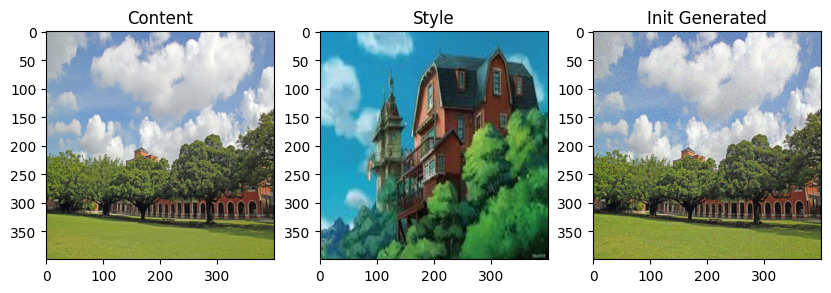

In [172]:
content_image = load_and_process_img("images/my_content.jpg")
style_image = load_and_process_img("images/my_styleG.jpg")
generated_image = tf.Variable(content_image)
noise = tf.random.uniform(tf.shape(generated_image), -20, 20)
generated_image = tf.add(generated_image, noise)
generated_image = tf.Variable(generated_image)


plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
plt.imshow(deprocess_img(content_image.numpy()))
plt.title("Content")

plt.subplot(1, 3, 2)
plt.imshow(deprocess_img(style_image.numpy()))
plt.title("Style")

plt.subplot(1, 3, 3)
plt.imshow(deprocess_img(generated_image.numpy()))
plt.title("Init Generated")
plt.show()

In [173]:
def get_layer_outputs(vgg, layer_names):
    """
    Creates a VGG model that returns a list of intermediate output values.

    Arguments:
    vgg -- Pre-trained VGG19 model
    layer_names -- List of tuples containing target layer names and weights.

    Returns:
    A Keras model that outputs the feature maps for all specified layers.
    """
    outputs = [vgg.get_layer(layer[0]).output for layer in layer_names]
    model = tf.keras.Model([vgg.input], outputs)
    return model

content_layer = [('block5_conv4', 1)]
vgg_model_outputs = get_layer_outputs(vgg, STYLE_LAYERS + content_layer)

# a_C: The feature maps extracted from the Content Image.
a_C = vgg_model_outputs(content_image)
# a_S: The feature maps extracted from the Style Image.
a_S = vgg_model_outputs(style_image)

In [174]:
def clip_0_255(image):
    """
    Truncate all the pixels in the tensor to be between 0 and 255

    Arguments:
    image -- Tensor
    J_style -- style cost coded above

    Returns:
    Tensor
    """
    return tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=255.0)

def tensor_to_image(tensor):
    """
    Converts a processed TensorFlow tensor into a displayable PIL Image.
    """
    return deprocess_img(tensor.numpy())

In [175]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.03)

@tf.function()
def train_step(alpha, beta, gamma, generated_image):
    """
    Performs one step of optimization on the generated image.

    """
    with tf.GradientTape() as tape:
        a_G = vgg_model_outputs(generated_image)
        J_style = compute_style_cost(a_S, a_G)
        J_content = compute_content_cost(a_C, a_G)
        J = total_cost(J_content, J_style, generated_image, alpha, beta, gamma)

    grad = tape.gradient(J, generated_image)
    optimizer.apply_gradients([(grad, generated_image)])
    generated_image.assign(tf.clip_by_value(generated_image, -150.0, 150.0))

    return J

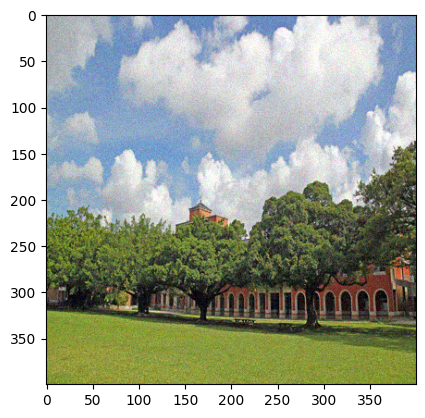

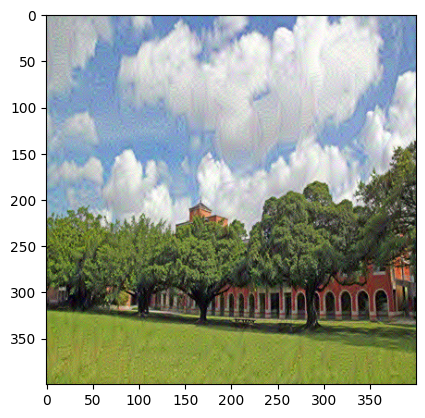

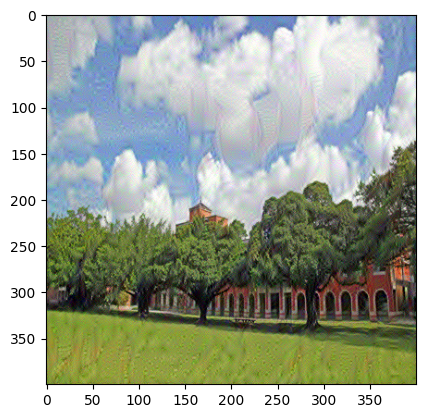

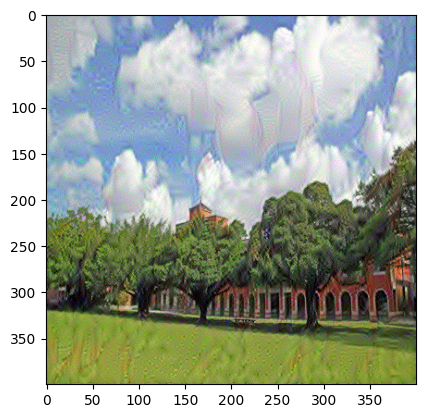

In [176]:
epochs = 1501
if not os.path.exists('output'):
    os.makedirs('output')
for i in range(epochs):
    train_step(10,400,400,generated_image)
    if i % 500 == 0:
        image = tensor_to_image(generated_image)
        imshow(image)
        image.save(f"output/result.jpg")
        plt.show()


